In [2]:
import pandas as pd


df = pd.read_parquet("../../data_lake/ml/datasets/df_validation.parquet")

In [3]:
df.describe()

,is_late_delivery,price,freight_value,total_item_value,product_weight_g,product_volume_cm3,purchase_ts
count,98578.000000,98578.000000,98578.000000,98578.000000,98578.000000,98578.000000,98578
mean,0.079663,123.998651,20.115983,144.114634,2093.895666,15147.261407,2018-01-02 16:43:37.752470
min,0.000000,0.850000,0.000000,6.080000,0.000000,168.000000,2016-09-15 12:16:38
25%,0.000000,40.500000,13.160000,57.090000,300.000000,2816.000000,2017-09-14 19:40:51
50%,0.000000,78.000000,16.350000,95.010000,700.000000,6400.000000,2018-01-21 17:20:04.500000
75%,0.000000,139.000000,21.250000,161.720000,1800.000000,18240.000000,2018-05-06 22:04:30
max,1.000000,6735.000000,409.680000,6929.310000,40425.000000,296208.000000,2018-08-29 15:00:37
std,0.270772,187.511020,15.826420,194.663766,3743.518645,23265.744154,NaN


In [4]:
df['is_late_delivery'].value_counts(normalize=True)

is_late_delivery
0    0.920337
1    0.079663
Name: proportion, dtype: float64

In [5]:
df.groupby("product_category_name")["is_late_delivery"].value_counts(normalize=True)

product_category_name      is_late_delivery
agro_industria_e_comercio  0                   0.949438
                           1                   0.050562
alimentos                  0                   0.898649
                           1                   0.101351
alimentos_bebidas          0                   0.937778
                                                 ...   
telefonia                  1                   0.085132
telefonia_fixa             0                   0.948113
                           1                   0.051887
utilidades_domesticas      0                   0.931574
                           1                   0.068426
Name: proportion, Length: 141, dtype: float64

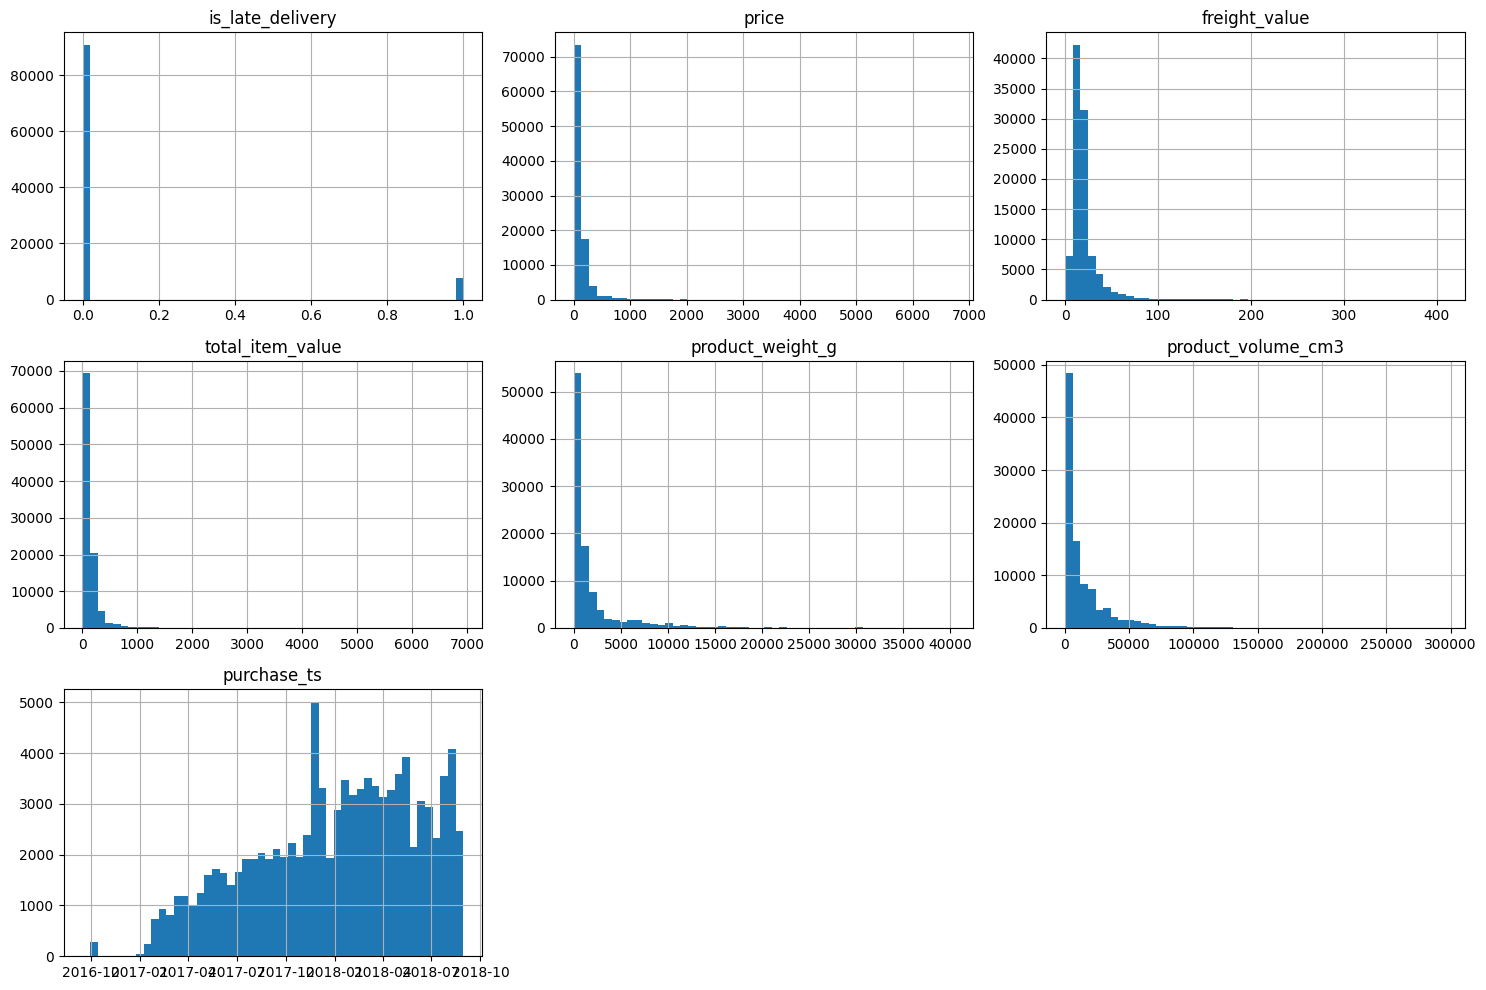

In [4]:
import matplotlib.pyplot as plt

df.hist(figsize=(15,10), bins=50)
plt.tight_layout()
plt.show()

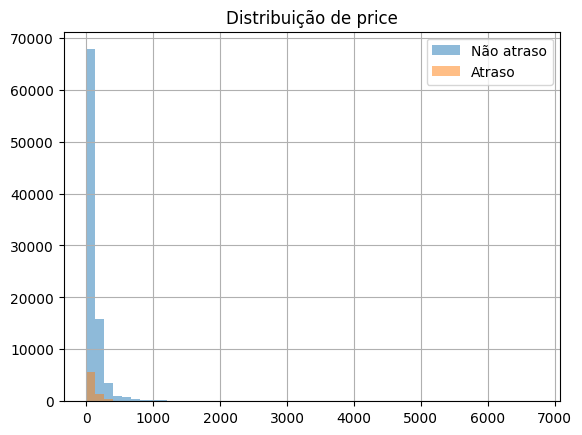

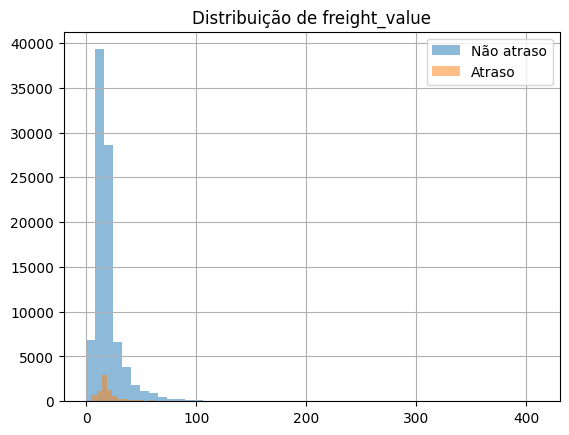

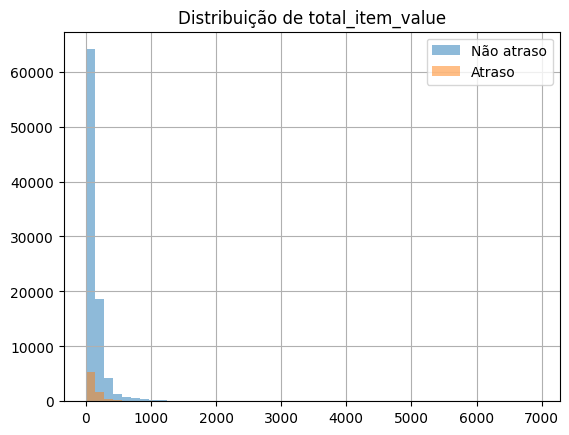

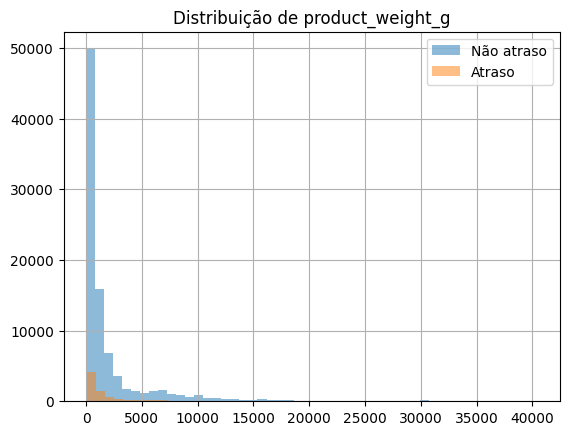

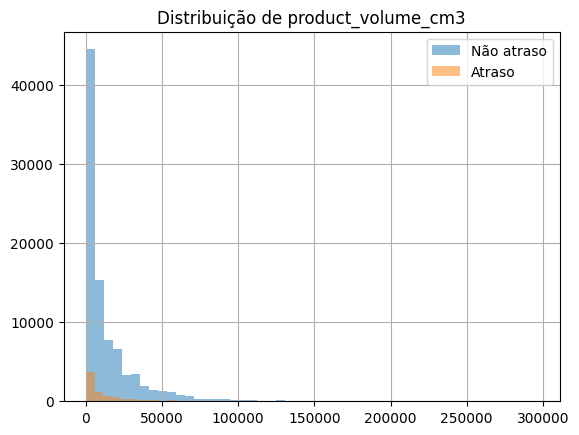

In [6]:
cols = [
    "price",
    "freight_value",
    "total_item_value",
    "product_weight_g",
    "product_volume_cm3"
]

for col in cols:
    plt.figure()
    
    df[df["is_late_delivery"] == 0][col].hist(alpha=0.5, bins=50, label="Não atraso")
    df[df["is_late_delivery"] == 1][col].hist(alpha=0.5, bins=50, label="Atraso")
    
    plt.title(f"Distribuição de {col}")
    plt.legend()
    plt.show()

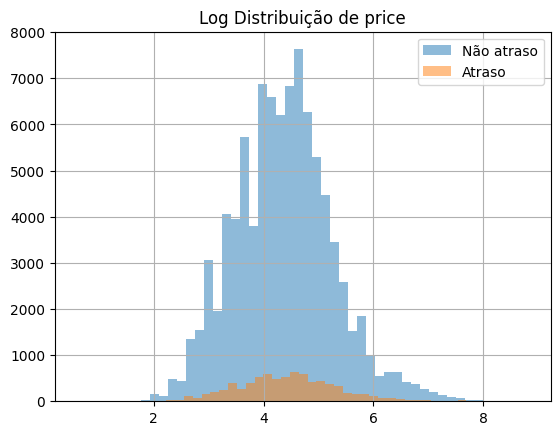

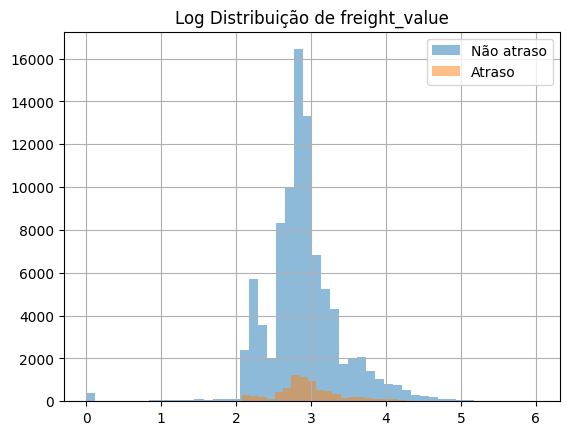

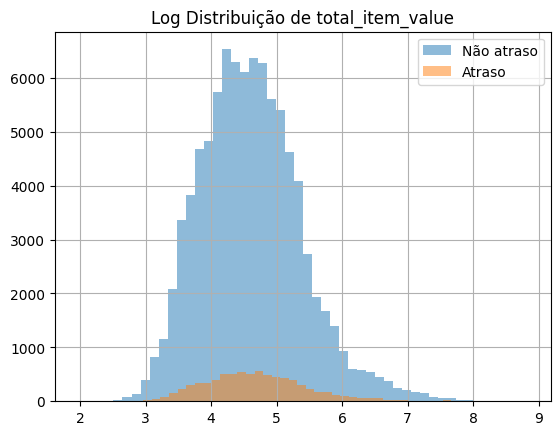

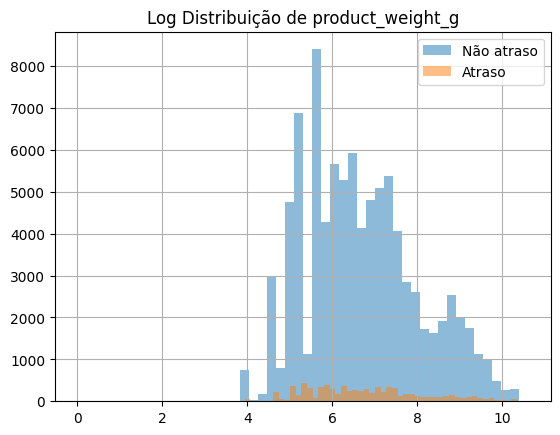

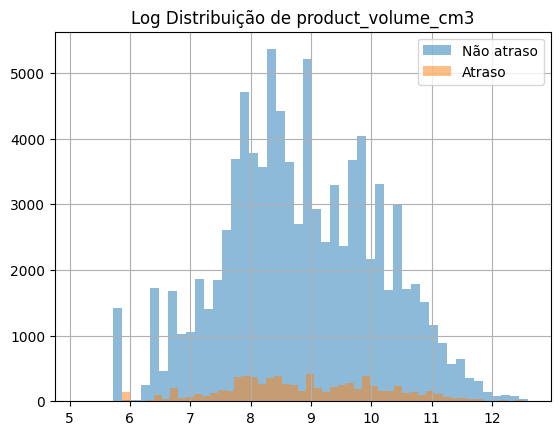

In [7]:
import numpy as np

for col in cols:
    plt.figure()
    
    np.log1p(df[df["is_late_delivery"] == 0][col]).hist(alpha=0.5, bins=50, label="Não atraso")
    np.log1p(df[df["is_late_delivery"] == 1][col]).hist(alpha=0.5, bins=50, label="Atraso")
    
    plt.title(f"Log Distribuição de {col}")
    plt.legend()
    plt.show()

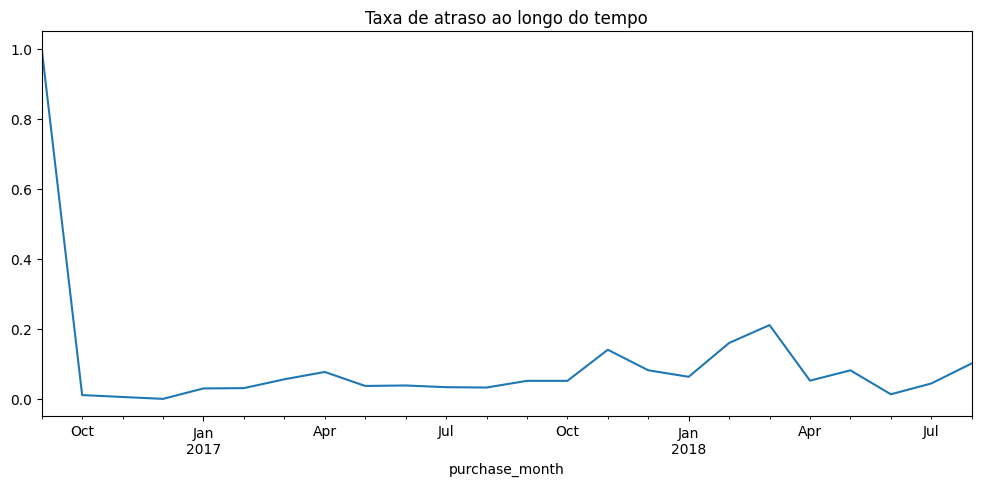

: 

In [ ]:
df["purchase_month"] = df["purchase_ts"].dt.to_period("M")

delay_rate = df.groupby("purchase_month")["is_late_delivery"].mean()

delay_rate.plot(figsize=(12,5), title="Taxa de atraso ao longo do tempo")
plt.show()